# Briefsummary Parser

Our high throughput dft code returns text files with a summary of calculation results. Here we convert this text files to a pandas dataframe containing all the information

We use some tools developed for this propose alone. The module `Featurizer` parses the strings in the `briefsummary.dat` files and recreates information of each sample as magnetic configuration, lattice occupation signatures, etc.

In [8]:
from Tools.DatasetTools.Commoms import *
#sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.brief_summary_parser import StructSummaryParser
os.environ['PATH'] += ':'+os.path.join(os.getcwd(), 'dependencies/bopfox/src')
dataset = 'Fe-Mo' # 'Cr-Co-W',  'Fe-Mo'
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.Featurizer import Featurizer

/home/storage/fortimtb/DatasetsML_2.0/dependencies/bopfox/src/bopfox


In [5]:
!which bopfox

In [7]:
from distutils.spawn import find_executable

In [8]:
find_executable('bopfox')

# Load Brief Summary

In [ ]:
BS = StructSummaryParser(dataset, ForceMakeBS=True).BriefSummary

In [3]:
!which bopfox

In [ ]:
BS.shape

In [ ]:
BS = BS[~BS.index.str.contains(r'\..*[UD]+$')]

In [ ]:
BS.shape

## Prepare targets 

One target still missing is formation Energy. Some Convenience functions to do this has been set

In [12]:
Features  = Featurizer(BS)

In [13]:
if 'Fe' in dataset:
    ground_states= Features.get_ground_states_energies(force_mag_phase=('Fe_pv', 'NM', 'fcc'))
else:
    ground_states = Features.get_ground_states_energies()

In [14]:
ground_states

{('Fe_pv2', 'bcc', 'FM'): -8.254843,
 ('Fe_pv2', 'hcp', 'NM'): -8.184069,
 ('Fe_pv4', 'fcc', 'NM'): -8.104999,
 ('Mo_sv1', 'bcc', 'FM'): -10.932791,
 ('Mo_sv1', 'bcc', 'NM'): -10.932826}

In [15]:
Features.get_ground_states_energies(force_mag_phase=('Fe_pv', 'NM', 'fcc'))

{('Fe_pv2', 'bcc', 'FM'): -8.254843,
 ('Fe_pv2', 'hcp', 'NM'): -8.184069,
 ('Fe_pv4', 'fcc', 'NM'): -8.104999,
 ('Mo_sv1', 'bcc', 'FM'): -10.932791,
 ('Mo_sv1', 'bcc', 'NM'): -10.932826}

In [16]:
ground_states

{('Fe_pv2', 'bcc', 'FM'): -8.254843,
 ('Fe_pv2', 'hcp', 'NM'): -8.184069,
 ('Fe_pv4', 'fcc', 'NM'): -8.104999,
 ('Mo_sv1', 'bcc', 'FM'): -10.932791,
 ('Mo_sv1', 'bcc', 'NM'): -10.932826}

As seen, at this point ground states are badly determined. They will be calculated after sanitation of dft data

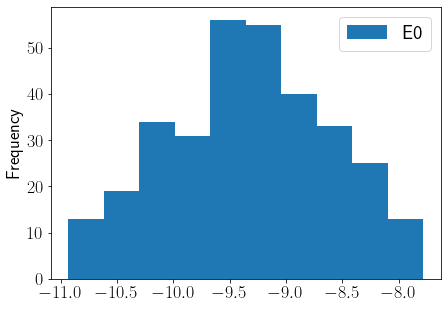

In [17]:
fig, ax =  plt.subplots()
for target_case in ['E0']:
    ax = BS[target_case].plot.hist(ax=ax, label = target_case)
ax.legend()

In [18]:
BS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,B0,V0,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv
Fe_pv8Mo_sv22.sigma-BBABB.FM,bulk sigma-BBABB.FM,14.954763 A,-10.004507,224.285410 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,224.285410,14.954763,Fe_pv,Mo_sv,8,22,30,0.266667,0.733333
Fe_pv10Mo_sv20.sigma-ABBAB.FM,bulk sigma-ABBAB.FM,14.130625 A,-10.006896,237.907324 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,237.907324,14.130625,Fe_pv,Mo_sv,10,20,30,0.333333,0.666667
Fe_pv4Mo_sv20.C36-ABBBB.FM,bulk C36-ABBBB.FM,16.270923 A,-10.007837,204.470374 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,204.470374,16.270923,Fe_pv,Mo_sv,4,20,24,0.166667,0.833333
Fe_pv3Mo_sv10.mu-ABBBA.FM,bulk mu-ABBBA.FM,15.378254 A,-10.008565,402.123952 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,402.123952,15.378254,Fe_pv,Mo_sv,3,10,13,0.230769,0.769231
Fe_pv5Mo_sv24.chi-AABB.FM,bulk chi-AABB.FM,15.751001 A,-10.015010,216.183583 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,216.183583,15.751001,Fe_pv,Mo_sv,5,24,29,0.172414,0.827586
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,bulk mu-ABBBA,15.125643 A,-9.973264,240.020984 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,240.020984,15.125643,Fe_pv,Mo_sv,3,10,13,0.230769,0.769231
Fe_pv8Mo_sv22.sigma-BBABB.NM,bulk sigma-BBABB,14.698886 A,-9.976143,247.238692 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,247.238692,14.698886,Fe_pv,Mo_sv,8,22,30,0.266667,0.733333
Fe_pv1Mo_sv3.L12-AB3.FM,bulk L12-AB3.FM,14.806728 A,-9.986411,223.435464 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,223.435464,14.806728,Fe_pv,Mo_sv,1,3,4,0.250000,0.750000
Fe_pv8Mo_sv22.sigma-BBBBA.FM,bulk sigma-BBBBA.FM,15.095159 A,-9.991080,207.683558 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,207.683558,15.095159,Fe_pv,Mo_sv,8,22,30,0.266667,0.733333


# Magnetic vs Non Magnetic

In [19]:
target_case = 'E0'

In [20]:
E0FM = BS[target_case][Features.Mag == 'FM']

In [21]:
E0NM = BS[target_case][Features.Mag == 'NM']

In [22]:
E0FM.index = E0FM.index.str.replace('.FM', '')

In [23]:
E0NM.index = E0NM.index.str.replace('.NM', '')

In [24]:
BS[target_case][Features.StrucNames == 'fcc']

Mo_sv1.fcc.NM         -10.511039
Mo_sv4.fcc-cubic.NM   -10.513041
Mo_sv4.fcc-cubic.FM   -10.513984
Fe_pv1.fcc.FM          -7.912043
Fe_pv4.fcc-cubic.FM    -8.060875
Fe_pv4.fcc-cubic.NM    -8.104999
Name: E0, dtype: float64

In [25]:
BS[target_case][Features.StrucNames == 'bcc']

Mo_sv1.bcc.FM         -10.932791
Mo_sv1.bcc.NM         -10.932826
Fe_pv1.bcc.NM          -7.790673
Fe_pv1.bcc.FM          -8.254018
Fe_pv2.bcc-cubic.FM    -8.254843
Name: E0, dtype: float64

In [26]:
BS[target_case][Features.StrucNames == 'hcp']

Mo_sv2.hcp.FM            -10.496688
Mo_sv2.hcp.NM            -10.497856
Fe_pv2.hcp.FM             -8.065630
Fe_pv2.hcp.NM             -8.184069
Fe_pv1Mo_sv1.hcp-AB.NM    -9.298898
Fe_pv1Mo_sv1.hcp-AB.FM    -9.298902
Name: E0, dtype: float64

In [27]:
DE_mag  = E0NM - E0FM 

In [28]:
DE_mag[ abs(DE_mag > 0.1)]

Fe_pv1.bcc                    0.463345
Fe_pv10Mo_sv14.C36-ABBAB      0.105985
Fe_pv10Mo_sv2.C14-ABA         0.181300
Fe_pv10Mo_sv3.mu-BAAAB        0.166282
Fe_pv11Mo_sv2.mu-AAAAB        0.178619
Fe_pv12.C14                   0.236066
Fe_pv12Mo_sv1.mu-BAAAA        0.176859
Fe_pv12Mo_sv12.C36-AAABB      0.110803
Fe_pv12Mo_sv18.sigma-BAABB    0.103115
Fe_pv13.mu                    0.206043
Fe_pv14Mo_sv10.C36-AABAB      0.210500
Fe_pv14Mo_sv10.C36-AABBA      0.147778
Fe_pv14Mo_sv10.C36-ABAAB      0.125409
Fe_pv14Mo_sv10.C36-BAABA      0.113570
Fe_pv14Mo_sv16.sigma-AAABB    0.107067
Fe_pv17Mo_sv12.chi-AAAB       0.114875
Fe_pv18Mo_sv6.C36-AAAAB       0.297771
Fe_pv18Mo_sv6.C36-AAABA       0.216094
Fe_pv1Mo_sv1.B2-AB            0.168504
Fe_pv20Mo_sv10.sigma-BAAAB    0.129429
Fe_pv20Mo_sv10.sigma-BAABA    0.128118
Fe_pv20Mo_sv4.C36-AABAA       0.183718
Fe_pv20Mo_sv4.C36-ABAAA       0.110802
Fe_pv20Mo_sv4.C36-BAAAA       0.124314
Fe_pv22Mo_sv8.sigma-AAAAB     0.132886
Fe_pv22Mo_sv8.sigma-AAABA

In [29]:
DE_mag[DE_mag < 0 ]

Fe_pv10Mo_sv14.C36-ABBBA    -0.004624
Fe_pv11Mo_sv2.mu-AAABA      -0.041939
Fe_pv13Mo_sv16.chi-ABBA     -0.000013
Fe_pv1Mo_sv28.chi-ABBB      -0.000003
Fe_pv2.hcp                  -0.118439
Fe_pv4.fcc-cubic            -0.044124
Fe_pv4Mo_sv20.C36-BABBB     -0.000004
Fe_pv4Mo_sv26.sigma-BABBB   -0.000186
Fe_pv4Mo_sv8.C14-ABB        -0.000004
Mo_sv1.bcc                  -0.000035
Mo_sv12.C14                 -0.001581
Mo_sv2.hcp                  -0.001168
Mo_sv24.C36                 -0.001591
Mo_sv29.chi                 -0.001359
Mo_sv30.sigma               -0.000013
Name: E0, dtype: float64

# some graphs for Raw 

In [30]:
plt.rc('figure', figsize=(18, 8))
plt.rc('font', size=26)
plt.rc('xtick', labelsize=26)
plt.rc('ytick', labelsize=26)
plt.rc('axes', labelsize=30)
from matplotlib.lines import Line2D

In [31]:
Features.StrucNames

Fe_pv8Mo_sv22.sigma-BBABB.FM     sigma
Fe_pv10Mo_sv20.sigma-ABBAB.FM    sigma
Fe_pv4Mo_sv20.C36-ABBBB.FM         C36
Fe_pv3Mo_sv10.mu-ABBBA.FM           mu
Fe_pv5Mo_sv24.chi-AABB.FM          chi
                                 ...  
Fe_pv3Mo_sv10.mu-ABBBA.NM           mu
Fe_pv8Mo_sv22.sigma-BBABB.NM     sigma
Fe_pv1Mo_sv3.L12-AB3.FM            L12
Fe_pv8Mo_sv22.sigma-BBBBA.FM     sigma
Fe_pv10Mo_sv20.sigma-ABBAB.NM    sigma
Length: 319, dtype: object

In [32]:
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.struct_db import struct_db
#struct_db = SourceFileLoader('struct_db','BopFoxFeaturizer/struct_db.py').load_module().struct_db
strucdic = struct_db().strucstrings

Target_Class = pd.Series(
    BS.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=BS.index
)
Target_Class[Target_Class.map(lambda s: s in strucdic['list.hcp'])]='hcp'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.fcc'])]='fcc'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.bcc'])]='bcc'
Target_Class[Features.Struc == 'hcp'] = 'hcp'
Target_Class[Features.Struc == 'bcc'] = 'bcc'
Target_Class[Features.Struc == 'fcc'] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-fcc')] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-L12')] = 'fcc'
Target_Class[Features.Struc.str.contains('sigma_')] = 'sigma'

Target_Class[    
    Target_Class.str.contains('Al42W') |\
    Target_Class.str.contains('Al9Co2') |\
    Target_Class.str.contains('Al5W') |\
    Target_Class.str.contains('Al12W') |\
    Target_Class.str.contains('Al4W') |\
    Target_Class.str.contains('Al5Co2')
] = 'others'

In [33]:
def do_mag(tag):
    if tag:
        return 'FM'
    else:
        return 'NM'

In [34]:
BS['Mag'] = BS.index.str.contains('FM')

In [35]:
BS['Mag'] = BS['Mag'].map(do_mag)

In [36]:
BS['Mag']

Fe_pv8Mo_sv22.sigma-BBABB.FM     FM
Fe_pv10Mo_sv20.sigma-ABBAB.FM    FM
Fe_pv4Mo_sv20.C36-ABBBB.FM       FM
Fe_pv3Mo_sv10.mu-ABBBA.FM        FM
Fe_pv5Mo_sv24.chi-AABB.FM        FM
                                 ..
Fe_pv3Mo_sv10.mu-ABBBA.NM        NM
Fe_pv8Mo_sv22.sigma-BBABB.NM     NM
Fe_pv1Mo_sv3.L12-AB3.FM          FM
Fe_pv8Mo_sv22.sigma-BBBBA.FM     FM
Fe_pv10Mo_sv20.sigma-ABBAB.NM    NM
Name: Mag, Length: 319, dtype: object

In [37]:
BS['Phase'] = Target_Class

In [38]:
BS = BS[~BS.index.str.contains('delta')]

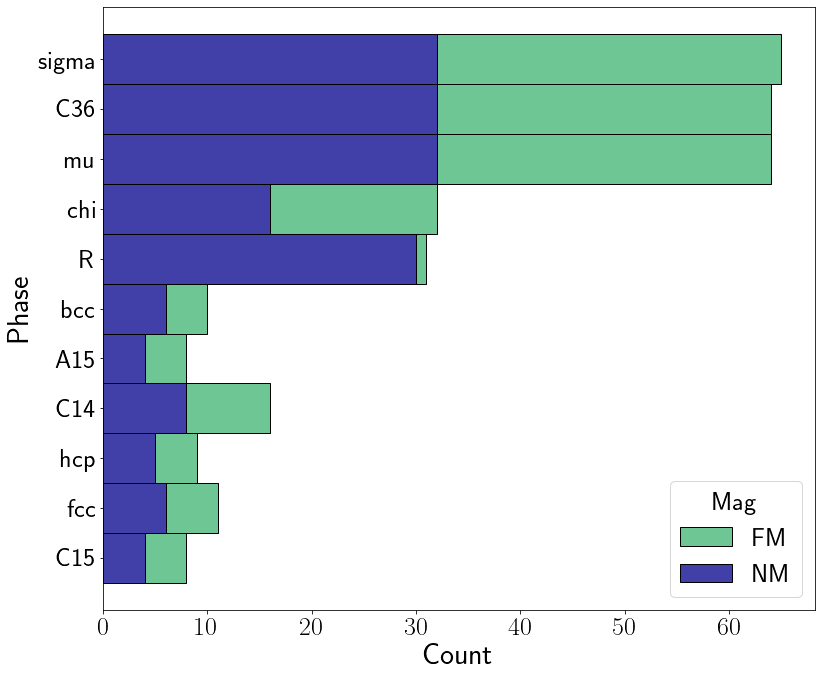

In [39]:
fig, ax = plt.subplots(figsize=(12,10))
sns.histplot(y=BS['Phase'], ax=ax, hue = BS['Mag'], multiple='stack', palette=['mediumseagreen', 'darkblue'], binwidth=0.1)
stack_histogram_file_name = os.path.join(dataset, 'graphs', f'{dataset}_StackCounts_RAW.pdf')
fig.tight_layout()
if not os.path.exists(os.path.dirname(stack_histogram_file_name)):
    os.makedirs(os.path.dirname(stack_histogram_file_name))
fig.savefig(stack_histogram_file_name)

In [40]:
BS.to_pickle(f'{dataset}/ParsedBriefsummary.pkl')